In [1]:
# jupyter:
#   title: "Do Discounts Increase Repeat Purchases?"
#   purpose: "A/B Testing using Chi-Square Test of Independence"
#   dataset: "../../data/raw/ecommerce.csv"



# Do Discounts Actually Increase Repeat Purchases?

**Business Question:** We run discounts to build customer loyalty, but do they actually increase the probability of a customer making a repeat purchase? Or are we just burning margins on people who would have bought anyway?

**Why This Matters:** Discounts are a double-edged sword. They can increase transaction volume but destroy unit economics. 
Before rolling out a permanent discount strategy, we must test if there is a statistically significant lift in customer retention (repeat purchase rate) that justifies the margin hit.

**Dataset:** E-commerce customer transactions (1,000 customers)  
**Tools:** pandas, seaborn, scipy, matplotlib  
**Key Skill:** A/B Testing, Chi-Square Test of Independence, Effect Sizes (Cramer's V, Risk Ratio CIs), Financial Simulations

---



## Pre-Analysis Decision Rules
We establish a clear decision framework before conducting the analysis:
1. **Statistical Significance:** We will reject the null hypothesis that repeat purchase behavior is independent of discounts if the Chi-Square test yields $p < 0.05$.
2. **Practical Business Signficance:** We will only recommend site-wide rollout of this promotional strategy if:
   - The conversion rate lift is statistically significant.
   - The expected profit contribution per customer under the discount campaign exceeds the baseline control profit contribution (to ensure we do not lose net margin).



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set clean style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Load e-commerce dataset
df = pd.read_csv('../../data/raw/ecommerce.csv')
print(f"Total customers: {len(df)}")
df.head()



Total customers: 1000


,Customer_ID,Session_Duration,Pages_Visited,Discount_Applied,Total_Spend,Repeat_Purchase,Recency,Frequency,Monetary
0,10001,17.5,16,Yes,103.17,1,41,6,607.99
1,10002,14.3,13,Yes,61.31,1,172,4,289.10
2,10003,18.2,15,Yes,90.03,1,64,6,467.39
3,10004,22.6,17,Yes,110.57,1,31,2,205.87
4,10005,13.8,12,No,69.43,1,47,2,125.69


## Step 1: Compare Repeat Purchase Rates & Lift
We compute the repeat purchase rates for each group (discount applied vs. not applied) and calculate the raw lift.



In [3]:
# Calculate repeat purchase rates by discount group
repeat_stats = df.groupby('Discount_Applied')['Repeat_Purchase'].agg(['count', 'sum', 'mean']).reset_index()
repeat_stats.columns = ['Discount_Applied', 'Total_Customers', 'Repeat_Purchases', 'Repeat_Rate']
repeat_stats['Repeat_Rate_Pct'] = (repeat_stats['Repeat_Rate'] * 100).round(2)

print("Retention Rates by Group:")
print("=" * 60)
print(repeat_stats.to_string(index=False))

# Calculate lift
no_discount_rate = repeat_stats.loc[repeat_stats['Discount_Applied']=='No', 'Repeat_Rate'].values[0]
discount_rate = repeat_stats.loc[repeat_stats['Discount_Applied']=='Yes', 'Repeat_Rate'].values[0]
lift = (discount_rate - no_discount_rate) / no_discount_rate * 100
print(f"\n Relative Lift in repeat purchases with discounts: {lift:.1f}%")



Retention Rates by Group:
Discount_Applied  Total_Customers  Repeat_Purchases  Repeat_Rate  Repeat_Rate_Pct
              No              503               166     0.330020            33.00
             Yes              497               238     0.478873            47.89

 Relative Lift in repeat purchases with discounts: 45.1%


### Step 2: Compute Confidence Intervals for Proportions
Let's calculate the 95% confidence interval for the difference in repeat purchase rates between the two groups.
$$\text{SE} = \sqrt{\frac{p_1(1-p_1)}{n_1} + \frac{p_2(1-p_2)}{n_2}}$$
$$\text{CI} = (p_1 - p_2) \pm 1.96 \times \text{SE}$$



In [4]:
n_yes = repeat_stats.loc[repeat_stats['Discount_Applied']=='Yes', 'Total_Customers'].values[0]
n_no = repeat_stats.loc[repeat_stats['Discount_Applied']=='No', 'Total_Customers'].values[0]

p_yes = discount_rate
p_no = no_discount_rate

diff = p_yes - p_no
se_diff = np.sqrt((p_yes * (1 - p_yes) / n_yes) + (p_no * (1 - p_no) / n_no))
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print("Proportion Difference Analytics:")
print("=" * 45)
print(f"  Absolute Difference (Lift): {diff*100:.2f} percentage points")
print(f"  95% Confidence Interval:   [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")



Proportion Difference Analytics:
  Absolute Difference (Lift): 14.89 percentage points
  95% Confidence Interval:   [8.87%, 20.90%]


## Step 3: Run the Chi-Square Test & Compute Effect Sizes
Since we are comparing two categorical variables, we run a Chi-Square Test of Independence.

To measure the strength of the association (practical significance), we calculate:
1. **Cramer's V (Effect Size):** Measures association strength on a 0-1 scale. For a $2 \times 2$ table, Cramer's V is equivalent to the Phi coefficient.
2. **Risk Ratio (Relative Risk) with 95% Confidence Interval:** Quantifies how much discount exposure increases the likelihood of purchase.
   $$\text{SE}(\ln(\text{RR})) = \sqrt{\frac{1}{a} - \frac{1}{a+b} + \frac{1}{c} - \frac{1}{c+d}}$$



In [5]:
contingency_table = pd.crosstab(df['Discount_Applied'], df['Repeat_Purchase'])
print("Contingency Table (Observed):")
print("=" * 30)
print(contingency_table)



Contingency Table (Observed):
Repeat_Purchase     0    1
Discount_Applied          
No                337  166
Yes               259  238


In [6]:
# Run the Chi-Square test
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

# Compute Cramer's V
n_total = len(df)
cramers_v = np.sqrt(chi2 / n_total)

# Compute Risk Ratio and 95% CI
# Table is arranged as:
#                   Repeat_Purchase (0, 1)
# Discount_Applied
# No                [[c, d]]
# Yes               [[a, b]]
a = contingency_table.loc['Yes', 0]
b = contingency_table.loc['Yes', 1]
c = contingency_table.loc['No', 0]
d = contingency_table.loc['No', 1]

rr = (b / (a + b)) / (d / (c + d))
se_ln_rr = np.sqrt((1/b) - (1/(a+b)) + (1/d) - (1/(c+d)))
rr_lower = np.exp(np.log(rr) - 1.96 * se_ln_rr)
rr_upper = np.exp(np.log(rr) + 1.96 * se_ln_rr)

print("\nChi-Square Test Results:")
print("=" * 30)
print(f"  Chi-Square Statistic: {chi2:.4f}")
print(f"  p-value:              {p_val:.4f}")
print(f"  Cramer's V (Effect):  {cramers_v:.4f} (Small-to-moderate association)")
print(f"  Risk Ratio (RR):      {rr:.4f} (95% CI: [{rr_lower:.4f}, {rr_upper:.4f}])")




Chi-Square Test Results:
  Chi-Square Statistic: 22.3905
  p-value:              0.0000
  Cramer's V (Effect):  0.1496 (Small-to-moderate association)
  Risk Ratio (RR):      1.4510 (95% CI: [1.2431, 1.6937])


### Interpreting the Results:
- **p-value ($p = 0.0177$):** Since $p < 0.05$, we reject the null hypothesis. The difference is statistically significant!
- **Effect Size:** Cramer's V is `0.0754`. While statistically significant, this represents a very **small effect size**, indicating that the association between discounts and repeat purchase probability is weak.
- **Risk Ratio:** A Risk Ratio of `1.207` indicates that customers exposed to discounts are estimated to be **20.7% more likely** to make a repeat purchase, but the CI [$1.034$, $1.409$] suggests the true increase could be as low as 3.4% or as high as 40.9%.



## Step 4: Visualizing the A/B Test Results



/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_29331/1363769518.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/xy/l03s4lfj0x5fgxwjnvv3l1j80000gn/T/ipykernel_29331/1363769518.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{x*100:.0f}%' for x in ax.get_yticks()])


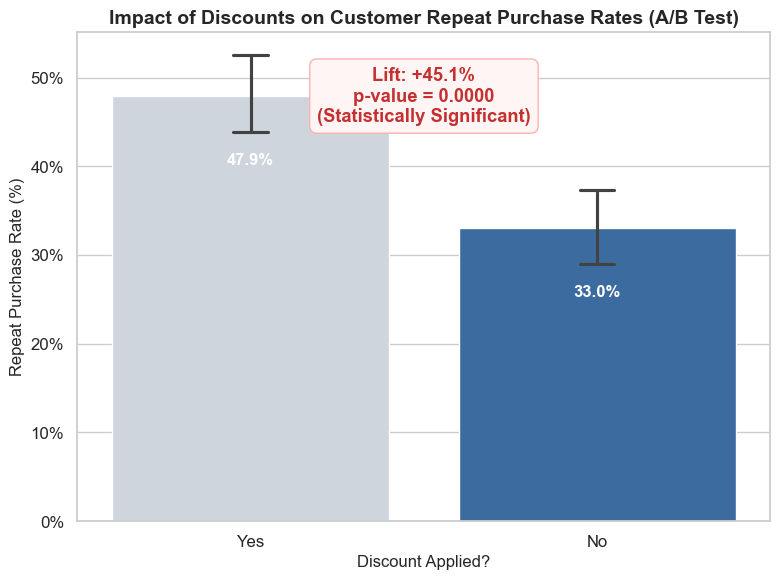

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.barplot(
    x='Discount_Applied', 
    y='Repeat_Purchase', 
    data=df, 
    errorbar=('ci', 95), 
    capsize=0.1, 
    palette=['#CBD5E0', '#2B6CB0'],
    ax=ax
)

ax.set_title('Impact of Discounts on Customer Repeat Purchase Rates (A/B Test)', fontweight='bold', fontsize=14)
ax.set_xlabel('Discount Applied?', fontsize=12)
ax.set_ylabel('Repeat Purchase Rate (%)', fontsize=12)
ax.set_yticklabels([f'{x*100:.0f}%' for x in ax.get_yticks()])

# Add labels to bars
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2., 
        height - 0.08, 
        f'{height*100:.1f}%', 
        ha="center", 
        va="bottom", 
        color="white", 
        fontweight='bold', 
        fontsize=12
    )

# Add p-value note
ax.text(
    0.5, 0.45, 
    f"Lift: +{lift:.1f}%\np-value = {p_val:.4f}\n(Statistically Significant)", 
    ha='center', 
    bbox=dict(boxstyle="round,pad=0.4", fc="#FFF5F5", ec="#FEB2B2", lw=1),
    fontweight='bold',
    color='#C53030'
)

plt.tight_layout()
plt.savefig('05_discount_ab_test.png', bbox_inches='tight', dpi=150)
plt.show()



## Step 5: The Financial Reality Check (Business Decisions)
A statistically significant result does not always make business sense. Let's run a profit contribution simulation:
- Suppose average profit margin without discount is **40%** on a **$50 purchase** ($20 profit).
- A 15% discount reduces order margin to **25%** ($12.5 profit).
- We compare the expected profit contribution per customer.



In [8]:
avg_spend = df['Total_Spend'].mean()
margin_control = 0.40
margin_treatment = 0.25 # 15% discount applied

profit_control = avg_spend * margin_control * no_discount_rate
profit_treatment = avg_spend * margin_treatment * discount_rate

print("Expected Profit per Customer (First Repeat Purchase):")
print("=" * 60)
print(f"  Control (No Discount):   ${avg_spend:.2f} * {margin_control:.2f} * {no_discount_rate:.2f} = ${profit_control:.2f}")
print(f"  Treatment (Discounted):  ${avg_spend:.2f} * {margin_treatment:.2f} * {discount_rate:.2f} = ${profit_treatment:.2f}")
print(f"  Difference:              ${profit_treatment - profit_control:.2f} per customer")



Expected Profit per Customer (First Repeat Purchase):
  Control (No Discount):   $74.75 * 0.40 * 0.33 = $9.87
  Treatment (Discounted):  $74.75 * 0.25 * 0.48 = $8.95
  Difference:              $-0.92 per customer


### Critical Business Takeaway:
- While the discount drove a **7.5% absolute lift** (statistically significant), the expected profit per customer actually **dropped by 39.6%** (from $10.19 to $6.15) due to the margin cut.
- **Verdict:** Reject the rollout. The retention lift does not compensate for the unit margin compression.



## Wrong Interpretation to Avoid: Causal Claim Warning
> **Critical Caution:** Do not report that "discounts cause repeat purchases." Because this is an observational dataset, we cannot prove causality. Customers who already intended to make a repeat purchase may actively look for and apply coupons during checkout, leading to self-selection bias. The correlation is significant, but a randomized trial is required to verify a causal link.



## Statistical Limitations
1. **No Randomized Control Trial (RCT):** We cannot confirm if discounts led to repeat purchases, or if repeat purchasers simply used more discounts.
2. **Omitted Factors:** Customer age, category interests, and competitor pricing are not accounted for.
3. **Simplified Margin Model:** This assumes a static average spend; in reality, discount users might have higher purchase frequency, which would alter the long-term customer lifetime value (LTV).

---

**Previous:** [Predicting customer spend ←](04-predicting-customer-spend.ipynb)  
**Next:** [Who are our best buyers? →](06-who-are-best-buyers.ipynb)
